# GPT reproduction first model

In [63]:
import torch

## Vocabulaty is fix

In [64]:
# 1. Read the input file.
import numpy as np

def generate_training_data_standard_distribution(size:int) -> str:
    data_int = np.random.randint(ord('a'),ord('z') + 1,size=size).tolist()
    return "".join([chr(x) for x in data_int])

def generate_training_data_special_pattern(size:int) -> str:
    data_int = []
    i = 0
    while i < size-1:
        # item = int(np.random.randint(ord('a'),ord('z') + 1))
        item = ord("a")
        data_int.append(item)
        i += 1
        if item == ord('a'):
            i += 1
            random2 = np.random.rand()
            if random2 <= 0.5:
                data_int.append(ord("b"))
            elif random2 > 0.5 and random2 <= 0.7:
                data_int.append(ord("c"))
            elif random2 > 0.7 and random2 <= 0.8:
                data_int.append(ord("d"))
            else:
                data_int.append(int(np.random.randint(ord('e'),ord('z') + 1)))
    if i != size:
        data_int.append(int(np.random.randint(ord('b'),ord('z') + 1)))
    return "".join([chr(x) for x in data_int])

generate_training_data = generate_training_data_special_pattern

training_data = generate_training_data(100000)
print(training_data[:100])

print("a",training_data.count("a"))
print("ab",training_data.count("ab"))
print("ac",training_data.count("ac"))
print("ad",training_data.count("ad"))
print("ad",training_data.count("ae"))



ababadabadacabababacacamacatabababadajaracacadadabacapamadabarabacacababababadacacabacabababacababab
a 50000
ab 25141
ac 9794
ad 5033
ad 448


In [65]:
class Vocabulary:
    def __init__(self,data):
        self.vocabulary = sorted(list(set(list(training_data))))
        self.stoi = { c:i for i,c in enumerate(self.vocabulary) }
        self.itos = { i:c for i,c in enumerate(self.vocabulary) }

# 3. Create decode and encode function
    def encode_data(self,input:str) -> list:
        return [self.stoi[x] for x in input ]

    def decode_data(self,input:list) -> str:
        return "".join([self.itos[x] for x in input ])

    def size(self) -> int:
        return len(self.vocabulary)

# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

text = training_data
vocabulary = Vocabulary(text)

## Convert string to data

In [66]:
# Create data
import torch # we use PyTorch: https://pytorch.org
data = torch.tensor(vocabulary.encode_data(text), dtype=torch.long)
data[:10]

tensor([0, 1, 0, 1, 0, 3, 0, 1, 0, 3])

## Split training and validataion data

In [67]:
# Let's now split up the data into train and validation sets
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

## Define block size and batch size

In [68]:
batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

torch.manual_seed(1337)
def get_batch(split,train_data):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train',train_data)
print(xb)
print(yb)

tensor([[ 1,  0,  1,  0,  1,  0,  1,  0],
        [10,  0,  2,  0,  5,  0, 12,  0],
        [ 0,  3,  0,  2,  0,  1,  0,  3],
        [ 0,  1,  0,  1,  0,  1,  0,  1]])
tensor([[ 0,  1,  0,  1,  0,  1,  0,  1],
        [ 0,  2,  0,  5,  0, 12,  0,  1],
        [ 3,  0,  2,  0,  1,  0,  3,  0],
        [ 1,  0,  1,  0,  1,  0,  1,  0]])


Ez a model most reprodukálja az lehetö legegyszerübb nyelvi modelt. Csak a loss kiszámítását tartalmazza, és a következö token generátor funkcióját

In [69]:
import torch
import torch.nn as nn
from torch.nn import functional as F


class LLM_Forward_Loss_Generator(nn.Module):  # What is the torch.nn.Module?

    def __init__(self, vocabulary: Vocabulary, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.token_embedding_table = nn.Embedding(vocabulary.size(), vocabulary.size())

    def forward(self, idx, targets=None):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx


torch.manual_seed(1337)
network = LLM_Forward_Loss_Generator(vocabulary)

logits, loss = network(xb, yb)
print(logits.shape)
print(loss)

print(vocabulary.decode_data(network.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


torch.Size([32, 26])
tensor(4.2466, grad_fn=<NllLossBackward0>)
asgxsgoqyyfumiievbyjzqfvjzsojhzwqyfaqbfdanvqwlnruqyfapzmifvfpqfojgfigdfdeznvfbfaqfsihhdkceejzwciyfpjg


In [70]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(network.parameters(), lr=1e-3)

In [71]:
batch_size = 32
for steps in range(10000): # increase number of steps for good results...

    # sample a batch of data
    xb, yb = get_batch('train',train_data)
    # evaluate the loss
    logits, loss = network(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

0.965182363986969


In [72]:
output = ""
for i in range(1000):
    prediction = vocabulary.decode_data(network.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=1)[0].tolist())
    # print(prediction)
    output += prediction
print(output[:100])

print("a",output.count("a"))
print("ab",output.count("ab"))
print("ac",output.count("ac"))
print("ad",output.count("ad"))
print("ae",output.count("ae"))

acabacacaracababahababacabacababacabababapacababadacacadacagabalarabacabasababayaqabacabadabacabadax
a 1000
ab 523
ac 203
ad 87
ae 9


In [73]:
w0 = network.token_embedding_table.weight.data[0]
sm = F.softmax(w0,dim=-1)
sm.shape, w0.shape

(torch.Size([26]), torch.Size([26]))

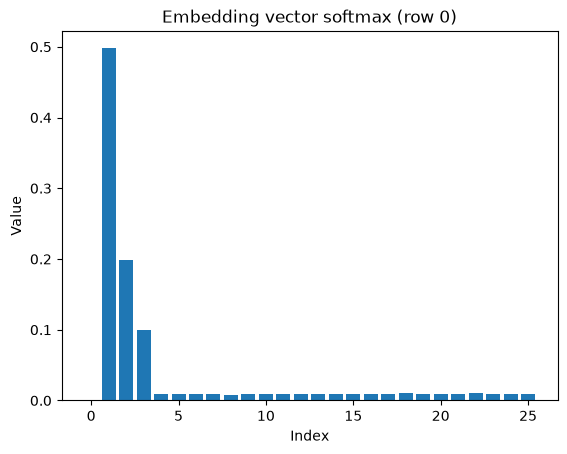

In [74]:

import matplotlib.pyplot as plt

vec = sm.cpu().numpy()

plt.bar(range(len(vec)), vec)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Embedding vector softmax (row 0)")
plt.show()
